In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
# Temperatures to calculate the cooling rate
tags_cooling = [
    "temp_1_23062026A_purewater",
    "temp_1_23062026O_purewater",
    "temp_1_24062026_purewater",
    "temp_2_23062026A_purewater",
    "temp_2_24062026_purewater",
    "2_0618",
    "2_0622A",
]

cooling_rates = [] 

# computing the cooling rate
for tag in tags_cooling:
    #importing data and making time array
    T = np.loadtxt(f"C:/BEP/Temperatures/{tag}.txt")
    t = np.arange(len(T))/60  # time in minutes
    #calculating average cooling rate by fitting a linear line through it and calculating the uncertainty (SD) in the average
    slope, intercept, r, p, stderr = linregress(t,T)
    cooling_rates.append(slope)
    print(f"{tag}: {slope:.3f} ± {stderr:.3f} °C/min, R^2 = {r**2:.4f}")

cooling_rates = np.array(cooling_rates)

#computing average and std across all experiments
mean_rate = np.mean(cooling_rates)
std_rate = np.std(cooling_rates, ddof=1)
print(f"Overall cooling rate = {mean_rate:.3f} ± {std_rate:.3f} °C/min")

temp_1_23062026A_purewater: -0.632 ± 0.001 °C/min, R^2 = 0.9947
temp_1_23062026O_purewater: -0.653 ± 0.001 °C/min, R^2 = 0.9951
temp_1_24062026_purewater: -0.563 ± 0.001 °C/min, R^2 = 0.9921
temp_2_23062026A_purewater: -0.620 ± 0.001 °C/min, R^2 = 0.9940
temp_2_24062026_purewater: -0.563 ± 0.001 °C/min, R^2 = 0.9921
2_0618: -0.582 ± 0.001 °C/min, R^2 = 0.9946
2_0622A: -0.636 ± 0.001 °C/min, R^2 = 0.9943
Overall cooling rate = -0.607 ± 0.037 °C/min


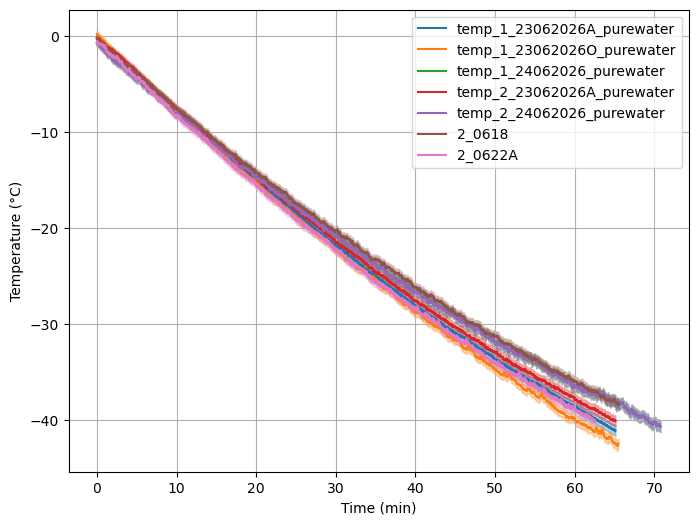

Overall cooling rate = -0.607 ± 0.037 °C/min


In [3]:
# Plotting the cooling rates with uncertainties
cooling_rates = []
cooling_errors = []

plt.figure(figsize=(8,6))

for tag in tags_cooling:
    T = np.loadtxt(f"C:/BEP/Temperatures/{tag}.txt")
    t = np.arange(len(T))/60
    slope, intercept, r, p, stderr = linregress(t, T)
    cooling_rates.append(slope)  #add slope to the list
    cooling_errors.append(stderr)

    # Uncertainty in Pt100 and MAX31865 to calculate total sigma
    sigma_T = 0.3 +0.005*np.abs(T)
    sigma_AMP = 0.1
    sigma_tot = np.sqrt(sigma_T**2 + sigma_AMP**2)

    line, = plt.plot(t, T, label=tag)
    plt.fill_between(
        t,
        T - sigma_T,
        T + sigma_T,
        color = line.get_color(),
        alpha=0.3
    )

plt.xlabel("Time (min)")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.savefig("cooling_rates.pdf")
plt.show()

cooling_rates = np.array(cooling_rates)

mean_rate = np.mean(cooling_rates)
std_rate = np.std(cooling_rates, ddof=1)

print(f"Overall cooling rate = {mean_rate:.3f} ± {std_rate:.3f} °C/min")

Average lab temperature for 3_0618: 23.838 ± 0.0 °C
Average lab temperature for 3_0622A: 25.731 ± 0.0 °C
Average lab temperature for 3_0623A: 26.236 ± 0.0 °C
Average lab temperature for 3_0623O: 25.262 ± 0.0 °C
Average lab temperature for 3_0624: 26.688 ± 0.0 °C


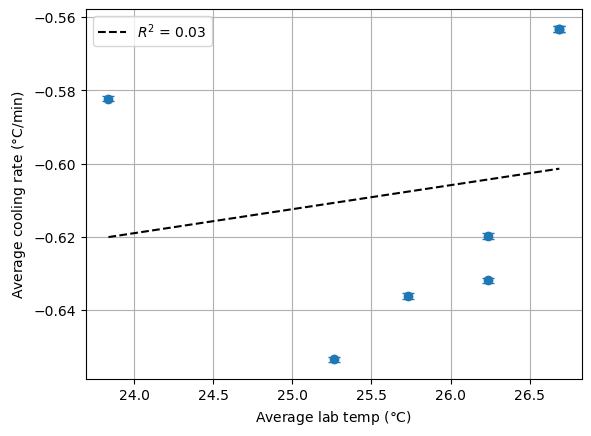

In [4]:
# tags for the ambient (lab) temperature
tags_ambient = ["3_0618",
                "3_0622A",
                "3_0623A",
                "3_0623O",
                "3_0624"
               ]

ambient_temps = []
#computing average lab temperature and standard deviation
for tag in tags_ambient:
    T = np.loadtxt(f"C:/BEP/Temperatures/{tag}.txt")
    mean_temp = np.mean(T)
    ambient_temps.append(mean_temp)
    print(f"Average lab temperature for {tag}: {np.round(mean_temp,3)} ± {np.std(mean_temp)} °C")

# plotting lab temp vs cooling rate:
# I did not have my data in order, so I will just make the list manaully
ambient_temps = np.array([ambient_temps[2], ambient_temps[3], ambient_temps[4], ambient_temps[2], ambient_temps[4], ambient_temps[0], ambient_temps[1]])
slope, intercept, r, p, stderr = linregress(ambient_temps, cooling_rates)

x = np.linspace(min(ambient_temps), max(ambient_temps), 100)

plt.plot(x, slope*x + intercept, 'k--',
         label=f"$R^2$ = {r**2:.2f}")
plt.legend()
plt.plot(ambient_temps, cooling_rates, '.')
#plotting errors for cooling rate
plt.errorbar(
    ambient_temps,
    cooling_rates,
    yerr=cooling_errors,
    fmt='o',
    capsize=4,
    color='tab:blue',
    label="Measurements"
)
plt.xlabel("Average lab temp ($\degree$C)")
plt.ylabel("Average cooling rate ($\degree$C/min)")
plt.savefig("cooling_rate(t).pdf")
plt.grid()